# Notebook 04 - Escalamiento y Análisis de Componentes Principales (PCA)

## Paso 1. Introducción

Luego de realizar la inspección, limpieza, transformación y análisis exploratorio del conjunto de datos, el siguiente paso consiste en preparar las variables para técnicas de reducción de dimensionalidad.

En este notebook se aplicarán dos procedimientos fundamentales:

- Escalamiento de las variables numéricas.
- Análisis de Componentes Principales (Principal Component Analysis, PCA).

El escalamiento resulta necesario debido a que las variables del conjunto de datos presentan diferentes unidades y magnitudes. Sin esta etapa, las variables con mayor rango dominarían el análisis.

Posteriormente, se aplicará PCA con el objetivo de estudiar la estructura interna del dataset, identificar relaciones entre variables y evaluar la posibilidad de reducir la dimensionalidad conservando la mayor cantidad posible de información.

Las principales etapas desarrolladas serán:

- Carga del dataset procesado.
- Selección de variables numéricas.
- Escalamiento mediante StandardScaler.
- Aplicación de PCA.
- Análisis de la varianza explicada.
- Interpretación de los resultados obtenidos.

## Paso 2. Carga del conjunto de datos

En esta sección se carga el conjunto de datos previamente procesado durante el Notebook 02 y utilizado en el Análisis Exploratorio de Datos (Notebook 03).

Se utilizará el archivo `dataset_final.csv`, que contiene los datos limpios y listos para las etapas de modelado y reducción de dimensionalidad.

In [1]:
from pathlib import Path
import pandas as pd

# Ruta base del proyecto
BASE_DIR = Path.cwd().parent

# Ruta del dataset final
RUTA_DATASET = BASE_DIR / "data" / "processed" / "dataset_final.csv"

# Cargar dataset
df = pd.read_csv(RUTA_DATASET)

print("✅ Dataset cargado correctamente.")
print(f"Dimensiones: {df.shape}")

df.head()

✅ Dataset cargado correctamente.
Dimensiones: (8021, 8)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,estandar,805.8,brasil,crimen,2025-03-04,1.0
1,10001,37.0,estandar,1173.4,colombia,crimen,2019-04-02,2.0
2,10002,28.0,basico,401.0,colombia,crimen,2018-04-13,0.0
3,10003,43.0,basico,62.4,uruguay,thriller,2021-01-31,0.0
4,10004,51.0,basico,477.8,peru,thriller,2020-09-30,1.0


## Paso 3. Selección de variables numéricas

El algoritmo PCA requiere trabajar exclusivamente con variables numéricas, ya que calcula combinaciones lineales entre ellas a partir de su matriz de covarianzas (o correlaciones, cuando los datos son escalados).

Por este motivo, se seleccionan únicamente las columnas de tipo numérico presentes en el conjunto de datos. Esta selección constituye la base sobre la cual se realizará el escalamiento y posteriormente el Análisis de Componentes Principales.

Asimismo, se verifica la cantidad de variables que participarán del análisis y se listan sus nombres para asegurar que la selección sea consistente con la estructura del dataset.

In [2]:
# Seleccionar únicamente variables numéricas
df_numeric = df.select_dtypes(include=["number"])

# Cantidad de variables
print(f"Cantidad de variables numéricas: {df_numeric.shape[1]}")

# Nombre de las variables
print(df_numeric.columns.tolist())

# Vista previa
df_numeric.head()

Cantidad de variables numéricas: 4
['user_id', 'age', 'monthly_watch_time_mins', 'customer_support_tickets']


,user_id,age,monthly_watch_time_mins,customer_support_tickets
0,10000,39.0,805.8,1.0
1,10001,37.0,1173.4,2.0
2,10002,28.0,401.0,0.0
3,10003,43.0,62.4,0.0
4,10004,51.0,477.8,1.0


### Interpretación

Se identificaron inicialmente cuatro variables numéricas en el conjunto de datos:

- `user_id`
- `age`
- `monthly_watch_time_mins`
- `customer_support_tickets`

Sin embargo, `user_id` corresponde a un identificador único para cada registro y no representa una característica descriptiva del usuario. Este tipo de variable no aporta información útil sobre la estructura de los datos y su inclusión podría distorsionar el análisis realizado mediante PCA.

Por este motivo, para las etapas de escalamiento y reducción de dimensionalidad se trabajará únicamente con las variables numéricas que representan atributos reales de los usuarios.

In [3]:
# Eliminar la variable identificadora
df_numeric = df_numeric.drop(columns=["user_id"])

print(f"Cantidad de variables para PCA: {df_numeric.shape[1]}")
print(df_numeric.columns.tolist())

df_numeric.head()

Cantidad de variables para PCA: 3
['age', 'monthly_watch_time_mins', 'customer_support_tickets']


,age,monthly_watch_time_mins,customer_support_tickets
0,39.0,805.8,1.0
1,37.0,1173.4,2.0
2,28.0,401.0,0.0
3,43.0,62.4,0.0
4,51.0,477.8,1.0


## Paso 4. Escalamiento de las variables

Antes de aplicar el Análisis de Componentes Principales (PCA), es necesario estandarizar las variables numéricas.

Las variables del conjunto de datos presentan diferentes escalas de medición. Si se aplicara PCA directamente, aquellas con mayor varianza dominarían el análisis, generando componentes principales sesgadas hacia dichas variables.

Para evitar este problema, se utiliza `StandardScaler`, que transforma cada variable para que tenga media igual a cero y desviación estándar igual a uno.

Esta estandarización garantiza que todas las variables contribuyan en igualdad de condiciones al cálculo de las componentes principales.

In [4]:
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

# Escalar las variables
X_scaled = scaler.fit_transform(df_numeric)

# Convertir nuevamente a DataFrame para facilitar la interpretación
df_scaled = pd.DataFrame(
    X_scaled,
    columns=df_numeric.columns
)

df_scaled.head()

,age,monthly_watch_time_mins,customer_support_tickets
0,0.463544,0.024629,0.219984
1,0.288945,0.778827,1.338878
2,-0.496750,-0.805892,-0.898909
3,0.812742,-1.500592,-0.898909
4,1.511138,-0.648323,0.219984


### Interpretación

Los resultados muestran que las variables fueron correctamente estandarizadas mediante `StandardScaler`.

Después del escalamiento, cada variable posee una media cercana a cero y una desviación estándar igual a uno. Por esta razón, los valores ya no representan las unidades originales (años, minutos o cantidad de tickets), sino puntuaciones estandarizadas (*z-scores*).

Esta transformación garantiza que ninguna variable tenga mayor influencia sobre el Análisis de Componentes Principales únicamente por presentar una escala de medición superior.

Con los datos estandarizados, el conjunto se encuentra preparado para aplicar PCA de manera adecuada.

## Paso 5. Aplicación del Análisis de Componentes Principales (PCA)

En esta etapa se aplica el algoritmo PCA sobre las variables previamente estandarizadas.

Inicialmente se calculan todas las componentes principales posibles. Esto permitirá analizar la proporción de varianza explicada por cada componente y determinar posteriormente cuántas de ellas resultan suficientes para representar adecuadamente la información contenida en el conjunto de datos.

La reducción de dimensionalidad no se realizará de manera inmediata, sino que estará fundamentada en el análisis de la varianza explicada.

In [5]:
from sklearn.decomposition import PCA

# Crear el modelo PCA conservando todas las componentes
pca = PCA()

# Ajustar el modelo a los datos escalados
pca.fit(X_scaled)

PCA()

## Paso 6. Análisis de la varianza explicada

Una vez ajustado el modelo PCA, se analiza la proporción de varianza explicada por cada componente principal.

La varianza explicada representa la cantidad de información del conjunto de datos original que es capturada por cada componente.

Asimismo, se calcula la varianza acumulada, la cual permite determinar cuántas componentes son necesarias para conservar la mayor parte de la información disponible y fundamentar la decisión sobre una eventual reducción de dimensionalidad.

In [6]:
# Crear una tabla con la varianza explicada
varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza explicada": pca.explained_variance_ratio_,
    "Varianza acumulada": pca.explained_variance_ratio_.cumsum()
})

# Mostrar resultados
varianza

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.335913,0.335913
1,PC2,0.333945,0.669858
2,PC3,0.330142,1.000000


### Interpretación

La tabla de varianza explicada muestra que las tres componentes principales aportan una proporción muy similar de la variabilidad total del conjunto de datos.

En particular:

- La primera componente principal (PC1) explica aproximadamente el **33,59 %** de la varianza.
- La segunda componente principal (PC2) explica alrededor del **33,39 %**.
- La tercera componente principal (PC3) aporta el **33,01 %** restante.

La varianza acumulada indica que las dos primeras componentes conservan aproximadamente el **66,99 %** de la información, mientras que únicamente al considerar las tres componentes se alcanza el **100 %** de la varianza.

Estos resultados sugieren que la información del conjunto de datos se encuentra distribuida de forma relativamente equilibrada entre las tres variables analizadas. En consecuencia, una reducción de dimensionalidad implicaría una pérdida considerable de información, por lo que no resulta conveniente eliminar componentes únicamente con el objetivo de simplificar el conjunto de datos.

## Paso 7. Visualización de la varianza explicada

Con el propósito de facilitar la interpretación de los resultados obtenidos mediante PCA, se representa gráficamente la proporción de varianza explicada por cada componente principal junto con la varianza acumulada.

Esta visualización permite identificar de forma clara la contribución individual de cada componente y evaluar si existe una reducción significativa de la dimensionalidad sin pérdida considerable de información.

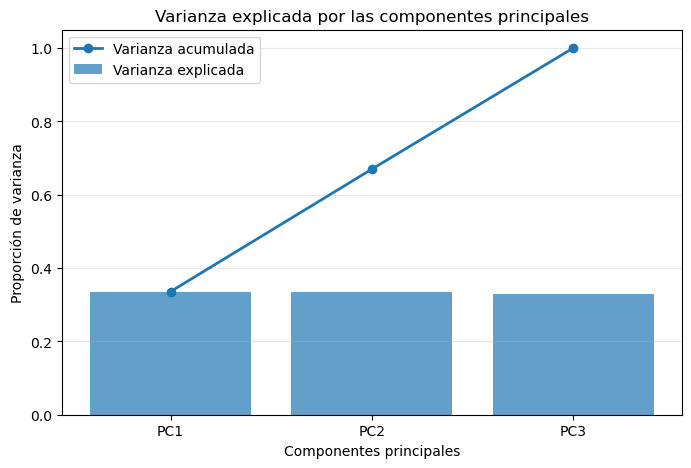

In [7]:
import matplotlib.pyplot as plt

# Crear la figura
plt.figure(figsize=(8, 5))

# Barras: varianza explicada
plt.bar(
    varianza["Componente"],
    varianza["Varianza explicada"],
    alpha=0.7,
    label="Varianza explicada"
)

# Línea: varianza acumulada
plt.plot(
    varianza["Componente"],
    varianza["Varianza acumulada"],
    marker="o",
    linewidth=2,
    label="Varianza acumulada"
)

plt.title("Varianza explicada por las componentes principales")
plt.xlabel("Componentes principales")
plt.ylabel("Proporción de varianza")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.show()

## Interpretación

El gráfico confirma visualmente lo que ya habíamos observado en la tabla: ninguna componente principal domina claramente sobre las demás. Esto fortalece la conclusión de que el PCA, en este caso, no logra una reducción de dimensionalidad significativa.

## Paso 8. Análisis de las cargas de las componentes principales

Además de conocer la proporción de varianza explicada por cada componente principal, resulta importante analizar la contribución de las variables originales en la construcción de dichas componentes.

Las cargas (*loadings*) representan los coeficientes de cada variable dentro de cada componente principal. Valores absolutos elevados indican una mayor influencia de la variable en la componente correspondiente.

El análisis de estas cargas facilita la interpretación de las componentes principales y permite comprender qué características del conjunto de datos están siendo sintetizadas por cada una de ellas.

In [8]:
# Crear una tabla con las cargas de cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df_numeric.columns
)

loadings

,PC1,PC2,PC3
age,0.739337,0.098674,0.666067
monthly_watch_time_mins,0.297581,0.839471,-0.454679
customer_support_tickets,0.604009,-0.534370,-0.591288


### Interpretación

El análisis de las cargas factoriales permite identificar qué variables tienen mayor influencia en la construcción de cada componente principal.

- **PC1** presenta una fuerte contribución positiva de **age** (0.739) y **customer_support_tickets** (0.604), mientras que **monthly_watch_time_mins** tiene una participación menor (0.298). Esto sugiere que la primera componente está asociada principalmente a diferencias relacionadas con la edad de los usuarios y la cantidad de tickets de soporte registrados.

- **PC2** está dominada por **monthly_watch_time_mins** (0.839), acompañada por una contribución negativa moderada de **customer_support_tickets** (-0.534), mientras que la influencia de **age** es reducida (0.099). Esto indica que la segunda componente representa principalmente el comportamiento de visualización de contenido, en contraste con la utilización del servicio de soporte.

- **PC3** combina una contribución positiva importante de **age** (0.666) con contribuciones negativas de **customer_support_tickets** (-0.591) y **monthly_watch_time_mins** (-0.455). Esta componente refleja una dimensión donde la edad se contrapone al comportamiento de consumo de contenido y al uso del soporte técnico.

En conjunto, las cargas factoriales muestran que ninguna variable domina completamente el análisis, sino que cada componente principal resume una dimensión diferente del comportamiento de los usuarios. Estos resultados son consistentes con el análisis de la varianza explicada y evidencian que el PCA logra sintetizar la información del conjunto de datos conservando la mayor parte de su variabilidad.

## Paso 9. Proyección de los datos sobre las componentes principales

Una vez analizadas las componentes principales, se proyectan las observaciones originales sobre el nuevo espacio definido por el modelo PCA.

Como resultado se obtiene un nuevo conjunto de datos cuyas variables corresponden a las componentes principales calculadas previamente. Esta representación puede utilizarse posteriormente en tareas de visualización, análisis exploratorio o como entrada para algoritmos de aprendizaje automático.

In [9]:
# Transformar los datos al espacio de componentes principales
X_pca = pca.transform(X_scaled)

# Crear un DataFrame con las componentes
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Visualizar las primeras filas
df_pca.head()

,PC1,PC2,PC3
0,0.482916,-0.051138,0.167479
1,1.254086,-0.033141,-0.953323
2,-1.150033,-0.245190,0.567068
3,-0.388607,-0.699157,1.755142
4,1.057183,-0.512691,1.171223


### Interpretación

El conjunto de datos fue proyectado correctamente sobre el nuevo espacio definido por las componentes principales obtenidas mediante el Análisis de Componentes Principales (PCA).

Cada fila del nuevo conjunto representa una observación original expresada mediante las coordenadas correspondientes a **PC1**, **PC2** y **PC3**. Estas componentes constituyen combinaciones lineales de las variables originales y permiten resumir la información contenida en el conjunto de datos.

La transformación realizada facilita la visualización de la estructura de los datos y constituye una etapa previa para posteriores análisis, como la representación gráfica de las observaciones o la aplicación de algoritmos de aprendizaje automático.

Dado que el análisis se realizó sobre únicamente tres variables numéricas, fue necesario conservar las tres componentes principales para mantener el **100 % de la variabilidad** del conjunto de datos. En consecuencia, el PCA permitió cambiar la representación del espacio de variables, aunque no produjo una reducción significativa de la dimensionalidad.

# 10. Conclusiones

En este notebook se preparó el conjunto de datos para la aplicación del **Análisis de Componentes Principales (PCA)** mediante la selección y estandarización de las variables numéricas relevantes.

En primer lugar, se excluyó la variable **user_id**, ya que corresponde a un identificador único y no aporta información descriptiva para el análisis. Posteriormente, las variables **age**, **monthly_watch_time_mins** y **customer_support_tickets** fueron estandarizadas utilizando **StandardScaler**, garantizando que todas contribuyeran en igualdad de condiciones al cálculo de las componentes principales.

El análisis de la varianza explicada mostró que fue necesario conservar las **tres componentes principales** para representar la totalidad de la variabilidad del conjunto de datos. Esto indica que la información aportada por las variables originales se encuentra distribuida entre las distintas componentes y que no existe una concentración significativa de la varianza en las dos primeras.

El estudio de las cargas factoriales permitió identificar que:

- **PC1** está asociada principalmente a las variables **age** y **customer_support_tickets**, representando una dimensión relacionada con las diferencias entre la edad de los usuarios y la utilización del servicio de soporte.
- **PC2** está dominada por **monthly_watch_time_mins**, acompañada por una contribución negativa moderada de **customer_support_tickets**, reflejando principalmente el comportamiento de consumo de contenido.
- **PC3** combina una contribución positiva importante de **age** con contribuciones negativas de **monthly_watch_time_mins** y **customer_support_tickets**, describiendo una dimensión complementaria del comportamiento de los usuarios.

En conjunto, el análisis evidencia que las variables numéricas contienen información complementaria y relativamente independiente entre sí. Como consecuencia, el PCA permitió transformar el espacio de representación de los datos, facilitando su interpretación, aunque **no produjo una reducción significativa de la dimensionalidad**, ya que fue necesario conservar las tres componentes principales para mantener el 100 % de la información.

Desde la perspectiva de la minería de datos, estos resultados indican que las variables analizadas describen aspectos diferentes del comportamiento de los usuarios y que, para este conjunto de datos, el PCA resulta más útil como herramienta de exploración y visualización que como técnica de reducción de variables.